## [``dyce``](https://posita.github.io/dyce/) translation of one example from [``markbrockettrobson/python_dice``](https://github.com/markbrockettrobson/python_dice#usage)

Select ``Run All Cells`` from the ``Run`` menu above.

In [1]:
# Install additional requirements if necessary
import warnings

from dyce.lifecycle import ExperimentalWarning

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    try:
        import dyce  # noqa: F401
    except (ImportError, ModuleNotFoundError):
        # See <https://jupyterlite.readthedocs.io/en/stable/howto/configure/simple_extensions.html#avoid-the-drift-of-versions-between-the-frontend-extension-and-the-python-package>
        requirements = ["dyce~=0.7.0"]
        try:
            import piplite  # pyrefly: ignore[missing-import] # ty: ignore[unresolved-import]

            await piplite.install(requirements, keep_going=True)
            # Work around <https://github.com/jupyterlite/jupyterlite/issues/838>
            from matplotlib import pyplot as plt

            plt.clf()
        except ImportError:
            import pip  # pyrefly: ignore[missing-import] # ty: ignore[unresolved-import]

            pip.main(["install", *requirements])

warnings.filterwarnings("ignore", category=ExperimentalWarning)

In [2]:
from dyce import H

save_roll = H(20)
burning_arch_damage = 10 @ H(6) + 10
pass_save = save_roll.ge(10)
damage_half_on_save = burning_arch_damage // (pass_save + 1)

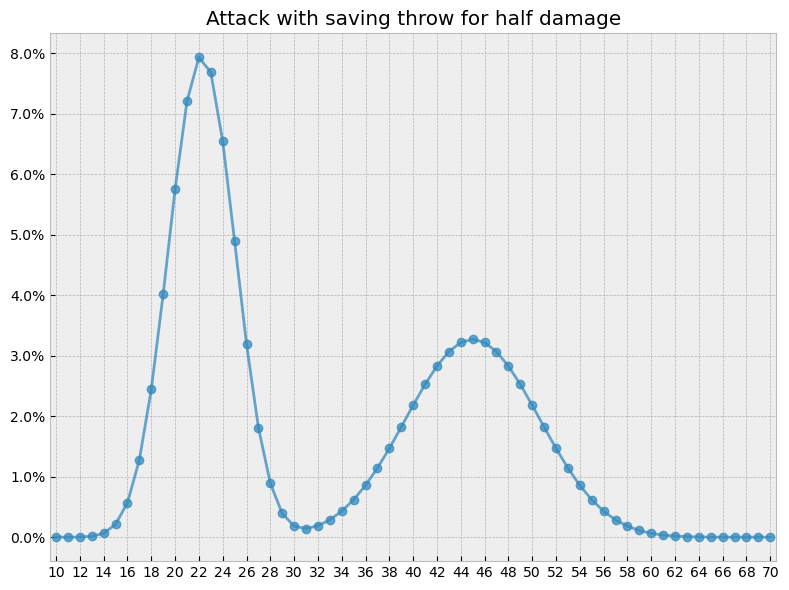

In [3]:
from matplotlib import pyplot as plt
from matplotlib import style, ticker

from dyce.viz import plot_line

plt.figure().set_size_inches(8, 6)
style.use("bmh")
ax = plot_line(damage_half_on_save)
ax.xaxis.set_major_locator(ticker.IndexLocator(base=2, offset=0))
ax.set_title("Attack with saving throw for half damage")
plt.tight_layout()